# ⚡ Energieverbruik Voorspellen met LSTM

**Vraag:** Kan een LSTM-model het energieverbruik van een huishouden voorspellen op basis van de afgelopen uren?

We vergelijken twee aanpakken:
- **Linear Regression** — klassiek model, ziet elke meting als onafhankelijk
- **LSTM** — ziet de laatste N uren als context en leert patronen over tijd

**Dataset:** [UCI – Individual Household Electric Power Consumption](https://archive.ics.uci.edu/ml/datasets/individual+household+electric+power+consumption)  
2.075.259 metingen (per minuut), van december 2006 tot november 2010.  
De data wordt automatisch gedownload in dit notebook.

---

## Waarom is dit een interessant probleem?

Energieverbruik is niet willekeurig — het heeft **geheugen en patronen**:
- 's Nachts verbruik je minder dan overdag → **dagcyclus**
- In de winter meer dan in de zomer → **seizoenscyclus**
- Na een piek (koken, wassen) volgt een daling → **temporele afhankelijkheid**
- Weekdagen vs weekenden → **weekcyclus**

Een klassiek model ziet elke meting als een **losse observatie**.  
Een LSTM ziet de **laatste N uren als een sequentie** en leert de patronen daarin herkennen.

```
Input:  [uur 1] [uur 2] ... [uur N]  →  LSTM  →  Voorspelling uur N+1
         ←——————— sequentie van N uren ————→      (verbruik in kW)
```


---
## 0 · Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, os, zipfile, io, requests

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error

import tensorflow as tf
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint

warnings.filterwarnings('ignore')
os.makedirs('results', exist_ok=True)

np.random.seed(42)
tf.random.set_seed(42)



---
## 1 · Data laden

De dataset wordt automatisch gedownload van de UCI repository.  
Het ZIP-bestand bevat een tekstbestand met **2+ miljoen metingen per minuut**.  

De kolommen:

| Kolom | Betekenis |
|---|---|
| `Global_active_power` | Totaal actief vermogen (kW) — **onze target** |
| `Global_reactive_power` | Reactief vermogen (kW) |
| `Voltage` | Spanning (volt) |
| `Global_intensity` | Stroomsterkte (ampère) |
| `Sub_metering_1` | Keuken (vaatwasser, oven, magnetron) |
| `Sub_metering_2` | Wasruimte (wasmachine, droger, koelkast, lamp) |
| `Sub_metering_3` | Boiler en airconditioning |

In [2]:
# Download dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip'
resp = requests.get(url, timeout=30)
resp.raise_for_status()

with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
    with z.open('household_power_consumption.txt') as f:
        raw = pd.read_csv(f, sep=';', low_memory=False,
                          na_values=['?', ''])

print(f"✅ Geladen: {len(raw):,} rijen × {raw.shape[1]} kolommen")
print(raw.columns)
raw.head()

✅ Geladen: 2,075,259 rijen × 9 kolommen
Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


---
## 2 · Opschonen & aggregeren naar uurdata

De ruwe data is **per minuut** — dat is te gedetailleerd voor ons doel.  
We aggregeren naar **uurgemiddelden**:

- Reduceert ruis (minuutschommelingen)
- Maakt de dataset beheersbaar (~35.000 rijen i.p.v. 2 miljoen)
- Sluit aan bij hoe energieleveranciers werkelijk voorspellen

We verwijderen ook rijen met missende waarden (~1.25% van de data).

In [3]:
# Datetime index maken
raw['datetime'] = pd.to_datetime(raw['Date'] + ' ' + raw['Time'],
                                  format='%d/%m/%Y %H:%M:%S')
raw = raw.drop(columns=['Date', 'Time']).set_index('datetime')

# Alles numeriek maken
for col in raw.columns:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

# Missende waarden verwijderen
missing_pct = raw.isnull().sum().sum() / raw.size * 100
print(f"Missende waarden: {missing_pct:.2f}%")
raw = raw.dropna()

# Aggregeren naar uurgemiddelden
hourly = raw.resample('h').mean().dropna()

print(f"\n✅ Uurdata: {len(hourly):,} rijen")
print(f"Periode  : {hourly.index.min()} → {hourly.index.max()}")
hourly.head()

Missende waarden: 1.25%

✅ Uurdata: 34,168 rijen
Periode  : 2006-12-16 17:00:00 → 2010-11-26 21:00:00


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


---
## 3 · Verkenning van de data

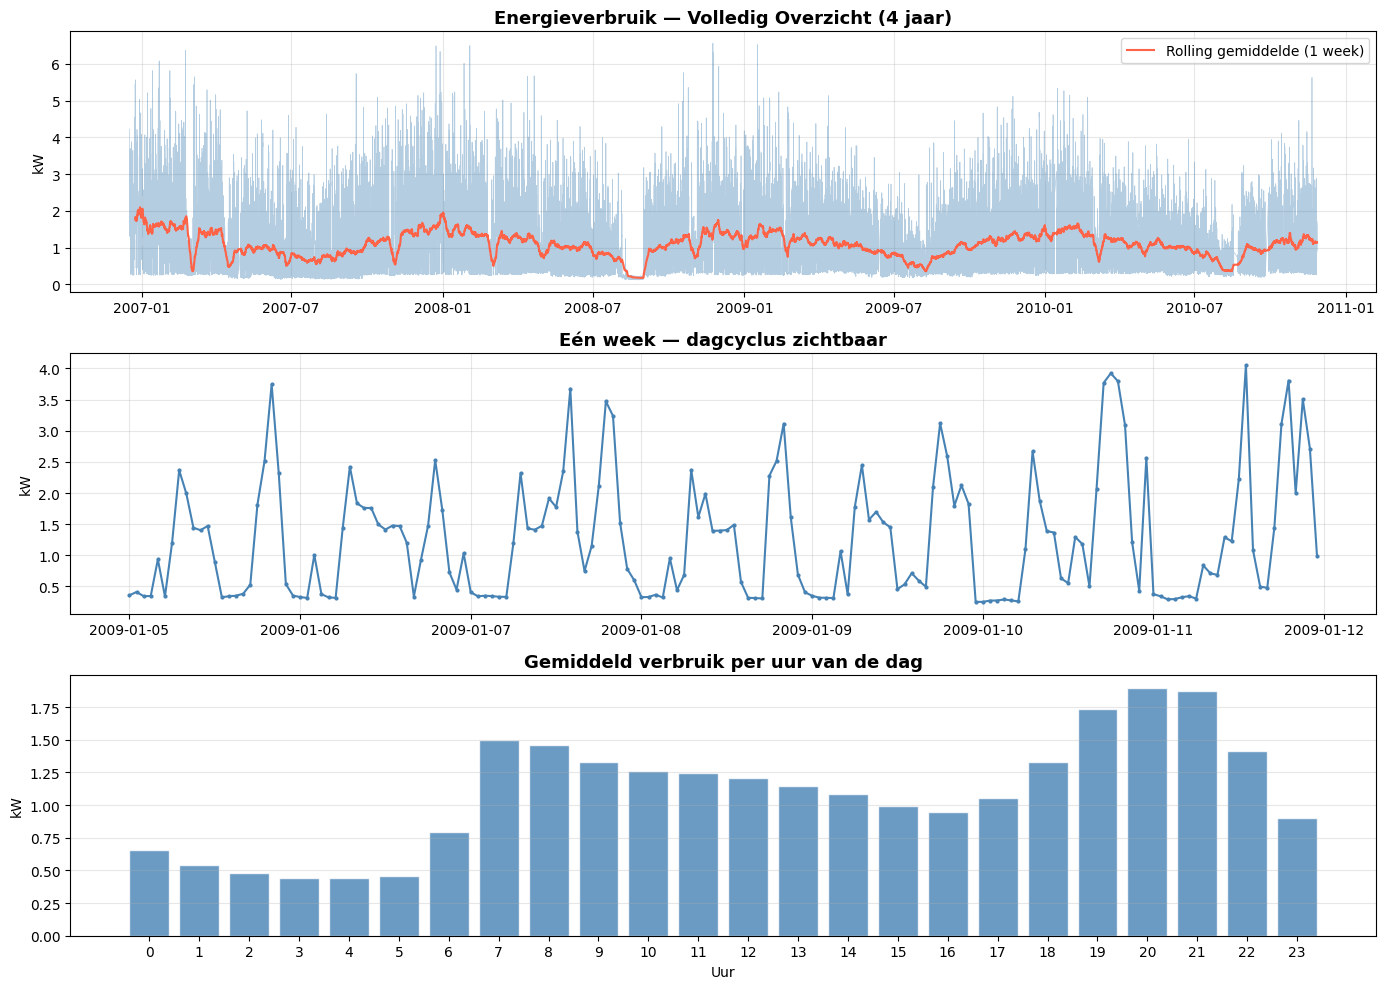


📊 Basisstatistieken: Global_active_power
count    34168.000
mean         1.092
std          0.898
min          0.124
25%          0.342
50%          0.803
75%          1.579
max          6.561


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Volledig overzicht
axes[0].plot(hourly.index, hourly['Global_active_power'], alpha=0.4,
             color='steelblue', lw=0.5)
axes[0].plot(hourly['Global_active_power'].rolling(24*7).mean(),
             color='tomato', lw=1.5, label='Rolling gemiddelde (1 week)')
axes[0].set_title('Energieverbruik — Volledig Overzicht (4 jaar)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('kW')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Eén week (dagcyclus zichtbaar)
week = hourly['2009-01-05':'2009-01-11']
axes[1].plot(week.index, week['Global_active_power'], color='steelblue',
             lw=1.5, marker='o', markersize=2)
axes[1].set_title('Eén week — dagcyclus zichtbaar', fontsize=13, fontweight='bold')
axes[1].set_ylabel('kW')
axes[1].grid(alpha=0.3)

# Gemiddeld verbruik per uur van de dag
hourly_avg = hourly.groupby(hourly.index.hour)['Global_active_power'].mean()
axes[2].bar(hourly_avg.index, hourly_avg.values, color='steelblue',
            edgecolor='white', alpha=0.8)
axes[2].set_title('Gemiddeld verbruik per uur van de dag', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Uur')
axes[2].set_ylabel('kW')
axes[2].set_xticks(range(0, 24))
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/01_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Basisstatistieken: Global_active_power")
print(hourly['Global_active_power'].describe().round(3).to_string())

---
## 4 · Feature Engineering

Energieverbruik heeft **context** nodig.  
We voegen tijdsgebonden features toe die de cyclische patronen vangen:

### A · Tijdsfeatures
| Feature | Wat vangt het? |
|---|---|
| `hour` | Uur van de dag (0-23) — dagcyclus |
| `day_of_week` | Dag van de week (0=ma, 6=zo) — weekcyclus |
| `month` | Maand (1-12) — seizoenscyclus |
| `is_weekend` | Weekend? (1/0) — ander verbruikspatroon |

### B · Cyclische encoding
Uur 23 en uur 0 liggen in werkelijkheid vlak naast elkaar, maar als gewoon getal (23 vs 0) lijken ze ver uit elkaar.  
We gebruiken **sinus/cosinus encoding** om deze cyclische relatie te vangen:

```
hour_sin = sin(2π × hour / 24)      hour_cos = cos(2π × hour / 24)

Uur 0:   sin=0.00, cos=1.00
Uur 6:   sin=1.00, cos=0.00
Uur 12:  sin=0.00, cos=-1.00
Uur 23:  sin=-0.26, cos=0.97   ← dicht bij uur 0! ✅
```

### C · Rolling features
| Feature | Wat meet het? |
|---|---|
| `rolling_mean_24h` | Gemiddeld verbruik afgelopen 24 uur |
| `rolling_std_24h` | Variatie in verbruik afgelopen 24 uur |
| `rolling_mean_168h` | Gemiddeld verbruik afgelopen week |

### ⚠️ Geen data leakage!
Alle rolling features worden berekend over **voorgaande** uren met `.shift(1)`.  
Het model ziet alleen informatie van **vóór** het uur dat het voorspelt.

In [5]:
df = hourly.copy()

# --- A · Tijdsfeatures -------------------------------------------------------
df['hour']        = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month']       = df.index.month
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

# --- B · Cyclische encoding --------------------------------------------------
df['hour_sin']  = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin']   = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# --- C · Rolling features (shifted → geen leakage) ---------------------------
df['rolling_mean_24h']  = df['Global_active_power'].rolling(24).mean().shift(1)
df['rolling_std_24h']   = df['Global_active_power'].rolling(24).std().shift(1)
df['rolling_mean_168h']  = df['Global_active_power'].rolling(168).mean().shift(1)


# Verwijder rijen met NaN (eerste 168 uur door rolling)
df = df.dropna().reset_index(drop=True)

print(f"✅ Features aangemaakt")
print(f"Dataset: {len(df):,} uur ({len(df)/24:.0f} dagen)")
print(f"Kolommen: {df.shape[1]}")

✅ Features aangemaakt
Dataset: 34,000 uur (1417 dagen)
Kolommen: 20


---
## 5 · Features & Target selectie

In [6]:
INPUT_FEATURES = [
    # Originele sensordata
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3',
    # Cyclische tijdsfeatures
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    # Context
    'is_weekend',
    # Rolling features
    'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_168h'

]
TARGET = 'Global_active_power'

print(f"Aantal features : {len(INPUT_FEATURES)}")
print(f"Target          : {TARGET}")
print(f"\nFeatures:")
for i, f in enumerate(INPUT_FEATURES, 1):
    print(f"  {i:2d}. {f}")

Aantal features : 17
Target          : Global_active_power

Features:
   1. Global_active_power
   2. Global_reactive_power
   3. Voltage
   4. Global_intensity
   5. Sub_metering_1
   6. Sub_metering_2
   7. Sub_metering_3
   8. hour_sin
   9. hour_cos
  10. dow_sin
  11. dow_cos
  12. month_sin
  13. month_cos
  14. is_weekend
  15. rolling_mean_24h
  16. rolling_std_24h
  17. rolling_mean_168h


> **Opmerking:** `Global_active_power` staat zowel als feature als target.  
> Als **input** gebruiken we het verbruik van de *vorige* uren — dit is geen data leakage  
> omdat we via de sliding window altijd het *volgende* uur voorspellen.  

---
## 6 · Sliding Window — het kernidee van LSTM-data-prep

In plaats van elk uur als losse observatie te behandelen, groeperen we ze in **overlappende vensters**.  
Elke stap schuift het venster één uur op:

```
Uur:   1    2    3  ...   N  →  [N+1]  (target: verbruik in kW)
       ←——— input sequentie (N uur) ——→

Uur:   2    3    4  ...  N+1 →  [N+2]  (target)
       ←——— input sequentie (N uur) ——→
       ...
```

Het resultaat is een 3D array `X` met shape `(samples, N, n_features)` — precies wat LSTM verwacht.

**We testen drie window groottes:**
- **24 uur** (1 dag) → vangt de dagcyclus
- **48 uur** (2 dagen) → vangt dag + vorige dag
- **168 uur** (1 week) → vangt het volledige weekpatroon
- **730 uur** (1 maand)


In [7]:
def build_sequences(data, features, target, seq_len):
    """Bouw sliding window sequenties voor een gegeven seq_len."""
    X_vals = data[features].values
    y_vals = data[target].values
    X, y = [], []
    for i in range(seq_len, len(X_vals)):
        X.append(X_vals[i - seq_len : i])
        y.append(y_vals[i])
    return np.array(X), np.array(y)

# Test
X_check, _ = build_sequences(df, INPUT_FEATURES, TARGET, seq_len=24)
print(f"Voorbeeld shape (seq=24): {X_check.shape}")
print(f"  → {X_check.shape[0]:,} samples × {X_check.shape[1]} tijdstappen × {X_check.shape[2]} features")

Voorbeeld shape (seq=24): (33976, 24, 17)
  → 33,976 samples × 24 tijdstappen × 17 features


---
## 7 · Train/Test Split & Normalisatie

We splitsen **chronologisch** (nooit random bij tijdreeksen) en schalen naar **[0, 1]**.  
De scaler wordt enkel gefit op de trainset om data leakage te vermijden.

In [8]:
def split_and_scale(X, y, seq_len, split_ratio=0.8):
    """Chronologische split en MinMax normalisatie."""
    split  = int(len(X) * split_ratio)
    n_feat = X.shape[2]

    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Normalisatie — fit alleen op train
    scaler = MinMaxScaler()
    X_train_sc = scaler.fit_transform(X_train.reshape(-1, n_feat)).reshape(-1, seq_len, n_feat)
    X_test_sc  = scaler.transform(X_test.reshape(-1, n_feat)).reshape(-1, seq_len, n_feat)

    return X_train_sc, X_test_sc, y_train, y_test, scaler

---
## 8 · Baseline — Linear Regression

Linear Regression krijgt exact dezelfde data als LSTM — de laatste N uren met alle features.  
Het cruciale verschil:

| | Linear Regression | LSTM |
|---|---|---|
| **Input** | N uren als platte vector | N uren als sequentie |
| **Volgorde** | ❌ Negeert de volgorde volledig | ✅ Leert patronen over tijd |
| **Relaties** | Enkel lineaire verbanden | Complexe, temporele relaties |

We trainen de baseline op **seq_len = 24** als referentiepunt.

In [9]:
# Baseline op seq_len = 24
X_base, y_base = build_sequences(df, INPUT_FEATURES, TARGET, seq_len=24)
X_train_base, X_test_base, y_train_base, y_test_base, _ = split_and_scale(X_base, y_base, seq_len=24)

lr = LinearRegression()
lr.fit(X_train_base.reshape(len(X_train_base), -1), y_train_base)
y_pred_lr = lr.predict(X_test_base.reshape(len(X_test_base), -1))

mae_lr  = mean_absolute_error(y_test_base, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_base, y_pred_lr))
r2_lr   = r2_score(y_test_base, y_pred_lr)
mape_lr = mean_absolute_percentage_error(y_test_base, y_pred_lr) * 100

print(f"Linear Regression (seq=24)")
print(f"  MAE  : {mae_lr:.4f} kW")
print(f"  RMSE : {rmse_lr:.4f} kW")
print(f"  MAPE : {mape_lr:.2f}%")
print(f"  R²   : {r2_lr:.4f}")

Linear Regression (seq=24)
  MAE  : 0.3598 kW
  RMSE : 0.5027 kW
  MAPE : 46.18%
  R²   : 0.5408


---
## 9 · LSTM Model — Architectuur

De architectuur is identiek voor alle drie de window groottes — enkel `input_shape` verschilt:

```
Input (N uren × 17 features)              ← N = 24, 48 of 168
         ↓
LSTM(64, return_sequences=True)
    → verwerkt de sequentie stap voor stap
    → return_sequences=True: geeft output van elke tijdstap door
         ↓
Dropout(0.3)  → voorkomt overfitting
         ↓
LSTM(32, return_sequences=False)
    → vat de hele sequentie samen in één vector van 32 getallen
         ↓
Dropout(0.2)
         ↓
Dense(16, activation='relu')
         ↓
Dense(1, activation='linear')  → output: één getal = voorspeld verbruik in kW
```

**Waarom `linear` als output activatie?**  
We doen regressie — we voorspellen een getal, geen kans.  
`linear` laat de output vrij zonder beperking.


In [10]:
def build_lstm(seq_len, n_feat):
    """Bouw een LSTM model voor energieverbruik voorspelling."""
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(seq_len, n_feat)),
        # Dropout(0.3),
        LSTM(32),
        # Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1,  activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Toon de architectuur
example_model = build_lstm(24, len(INPUT_FEATURES))
example_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,953 (132.63 KB)

 Trainable params: 33,953 (132.63 KB)

 Non-trainable params: 0 (0.00 B)

---
## 10 · Training — alle drie de window groottes

We trainen drie aparte LSTM-modellen, elk met een andere sequence length.  
`EarlyStopping` stopt de training automatisch als de validatie-loss niet meer verbetert na 10 epochs,  
en herstelt de gewichten van het beste moment (`restore_best_weights=True`).

**Let op:** seq=168 (1 week) heeft grote sequences en duurt het langst om te trainen.  
In Colab duurt de volledige training ~5-15 minuten afhankelijk van GPU-beschikbaarheid.

In [11]:
# SEQ_LENGTHS = [24, 48, 168]
# results     = {}

# for seq_len in SEQ_LENGTHS:
#     print(f"\n{'='*55}")
#     print(f"  Training LSTM — sequence length: {seq_len} uur"
#           f" ({seq_len//24} dag{'en' if seq_len//24 != 1 else ''})")
#     print(f"{'='*55}")

#     # Data prep
#     X, y = build_sequences(df, INPUT_FEATURES, TARGET, seq_len)
#     X_train_sc, X_test_sc, y_train, y_test, scaler = split_and_scale(X, y, seq_len)
#     n_feat = X_train_sc.shape[2]

#     print(f"  Train: {len(X_train_sc):,} samples | Test: {len(X_test_sc):,} samples")

#     # Model bouwen en trainen
#     model      = build_lstm(seq_len, n_feat)
#     early_stop = EarlyStopping(monitor='val_loss', patience=10,
#                                restore_best_weights=True, verbose=0)
#     checkpoint = ModelCheckpoint(
#     filepath=f'/content/drive/MyDrive/LSTM_models/best_lstm_seq{seq_len}.keras',
#     monitor='val_loss',
#     save_best_only=True,
#     verbose=0
# )

#     history = model.fit(
#         X_train_sc, y_train,
#         epochs=50, batch_size=64,
#         validation_split=0.15,
#         callbacks=[early_stop, checkpoint],
#         verbose=0
#     )

#     # Voorspellingen
#     y_pred = model.predict(X_test_sc, verbose=0).flatten()

#     # Metrics
#     mae  = mean_absolute_error(y_test, y_pred)
#     rmse = np.sqrt(mean_squared_error(y_test, y_pred))
#     r2   = r2_score(y_test, y_pred)
#     mape = mean_absolute_percentage_error(y_test, y_pred) * 100  # als percentage

#     # Sla alles op
#     results[seq_len] = {
#         'model'   : model,
#         'history' : history,
#         'y_test'  : y_test,
#         'y_pred'  : y_pred,
#         'scaler'  : scaler,
#         'X_test'  : X_test_sc,
#         'mae'     : mae,
#         'rmse'    : rmse,
#         'r2'      : r2,
#         'mape'    : mape
#     }

#     epochs_ran = len(history.history['loss'])
#     print(f"  Gestopt na {epochs_ran} epochs")
#     print(f"  MAE  : {mae:.4f} kW")
#     print(f"  RMSE : {rmse:.4f} kW")
#     print(f"  R²   : {r2:.4f}")
#     print(f"  MAPE : {mape:.2f}%")

In [16]:
import os
import requests

# Modellen downloaden vanuit GitHub
GITHUB_BASE = 'https://raw.githubusercontent.com/AP6-coder/Advanced_ML_LSTM/main/notebooks/LSTM_models/'
SEQ_LENGTHS = [24, 48, 168, 730]
os.makedirs('LSTM_models', exist_ok=True)

for seq_len in SEQ_LENGTHS:
    filename = f'best_lstm_seq{seq_len}.keras'
    local_path = f'LSTM_models/{filename}'
    if not os.path.exists(local_path):
        r = requests.get(GITHUB_BASE + filename)
        with open(local_path, 'wb') as f:
            f.write(r.content)

# Modellen laden
results = {}
labels = {24: '1 dag (24h)', 48: '2 dagen (48h)', 168: '1 week (168h)', 730: '1 maand (730h)'}

for seq_len in SEQ_LENGTHS:
    X, y = build_sequences(df, INPUT_FEATURES, TARGET, seq_len)
    X_train_sc, X_test_sc, y_train, y_test, scaler = split_and_scale(X, y, seq_len)
    model = load_model(f'LSTM_models/best_lstm_seq{seq_len}.keras')
    y_pred = model.predict(X_test_sc, verbose=0).flatten()

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    results[seq_len] = {
        'model': model, 'y_test': y_test, 'y_pred': y_pred,
        'X_test': X_test_sc, 'scaler': scaler,
        'mae': mae, 'rmse': rmse, 'r2': r2, 'mape': mape
    }
    print(f'LSTM {labels[seq_len]} — MAE: {mae:.4f} | RMSE: {rmse:.4f} | MAPE: {mape:.2f}% | R²: {r2:.4f}')

LSTM 1 dag (24h) — MAE: 0.3361 | RMSE: 0.4752 | MAPE: 43.28% | R²: 0.5898
LSTM 2 dagen (48h) — MAE: 0.3314 | RMSE: 0.4811 | MAPE: 38.77% | R²: 0.5770
LSTM 1 week (168h) — MAE: 0.3256 | RMSE: 0.4793 | MAPE: 37.72% | R²: 0.5803
LSTM 1 maand (730h) — MAE: 0.3266 | RMSE: 0.4754 | MAPE: 39.17% | R²: 0.5827


---
## 11 · Evaluatie — Overzicht

We evalueren alle modellen op vier vlakken:

1. **KPI-vergelijking** — MAE, RMSE, MAPE en R² naast elkaar (tabel + barplot)
2. **Voorspelling vs werkelijkheid** — tijdreeksplot van een voorbeeldweek
3. **Foutenverdeling** — histogram van de fouten per model
4. **Scatterplot** — voorspeld vs werkelijk (hoe dichter bij de diagonaal, hoe beter)

### Metrics uitleg

| Metric | Wat meet het? | Ideale waarde |
|---|---|---|
| **MAE** | Gemiddelde absolute fout (in kW) | 0 |
| **RMSE** | Gewogen fout — straft grote fouten harder (in kW) | 0 |
| **MAPE** | Gemiddelde procentuele fout | 0% |
| **R²** | Hoeveel variatie verklaart het model? | 1.0 (100%) |

---
### 11.1 · KPI-vergelijking

In [13]:
# Bouw vergelijkingstabel
comparison = pd.DataFrame({
    'Model': ['Linear Regression (seq=24)',
              'LSTM (seq=24, 1 dag)',
              'LSTM (seq=48, 2 dagen)',
              'LSTM (seq=168, 1 week)',
              'LSTM (seq=730, 1 maand)'],
    'MAE (kW)':  [mae_lr]  + [results[s]['mae']  for s in SEQ_LENGTHS],
    'RMSE (kW)': [rmse_lr] + [results[s]['rmse'] for s in SEQ_LENGTHS],
    'MAPE (%)':  [mape_lr] + [results[s]['mape'] for s in SEQ_LENGTHS],
    'R²':        [r2_lr]   + [results[s]['r2']   for s in SEQ_LENGTHS]
})

# Markeer het beste model
print("📊 KPI-vergelijking — alle modellen")
print("=" * 75)
display(comparison.style
    .highlight_min(subset=['MAE (kW)', 'RMSE (kW)', 'MAPE (%)'], color='lightgreen')
    .highlight_max(subset=['R²'], color='lightgreen')
    .format({'MAE (kW)': '{:.4f}', 'RMSE (kW)': '{:.4f}',
             'MAPE (%)': '{:.2f}', 'R²': '{:.4f}'})
)

📊 KPI-vergelijking — alle modellen


,Model,MAE (kW),RMSE (kW),MAPE (%),R²
0,Linear Regression (seq=24),0.3598,0.5027,46.18,0.5408
1,"LSTM (seq=24, 1 dag)",0.3361,0.4752,43.28,0.5898
2,"LSTM (seq=48, 2 dagen)",0.3314,0.4811,38.77,0.5770
3,"LSTM (seq=168, 1 week)",0.3256,0.4793,37.72,0.5803
4,"LSTM (seq=730, 1 maand)",0.3266,0.4754,39.17,0.5827


---
### 11.2 · Voorspelling vs Werkelijkheid — voorbeeldweek

We plotten het **beste LSTM-model** naast Linear Regression voor een week uit de testset.  
Zo zie je visueel hoe goed het model de pieken en dalen volgt.

Beste model: LSTM seq=168 uur


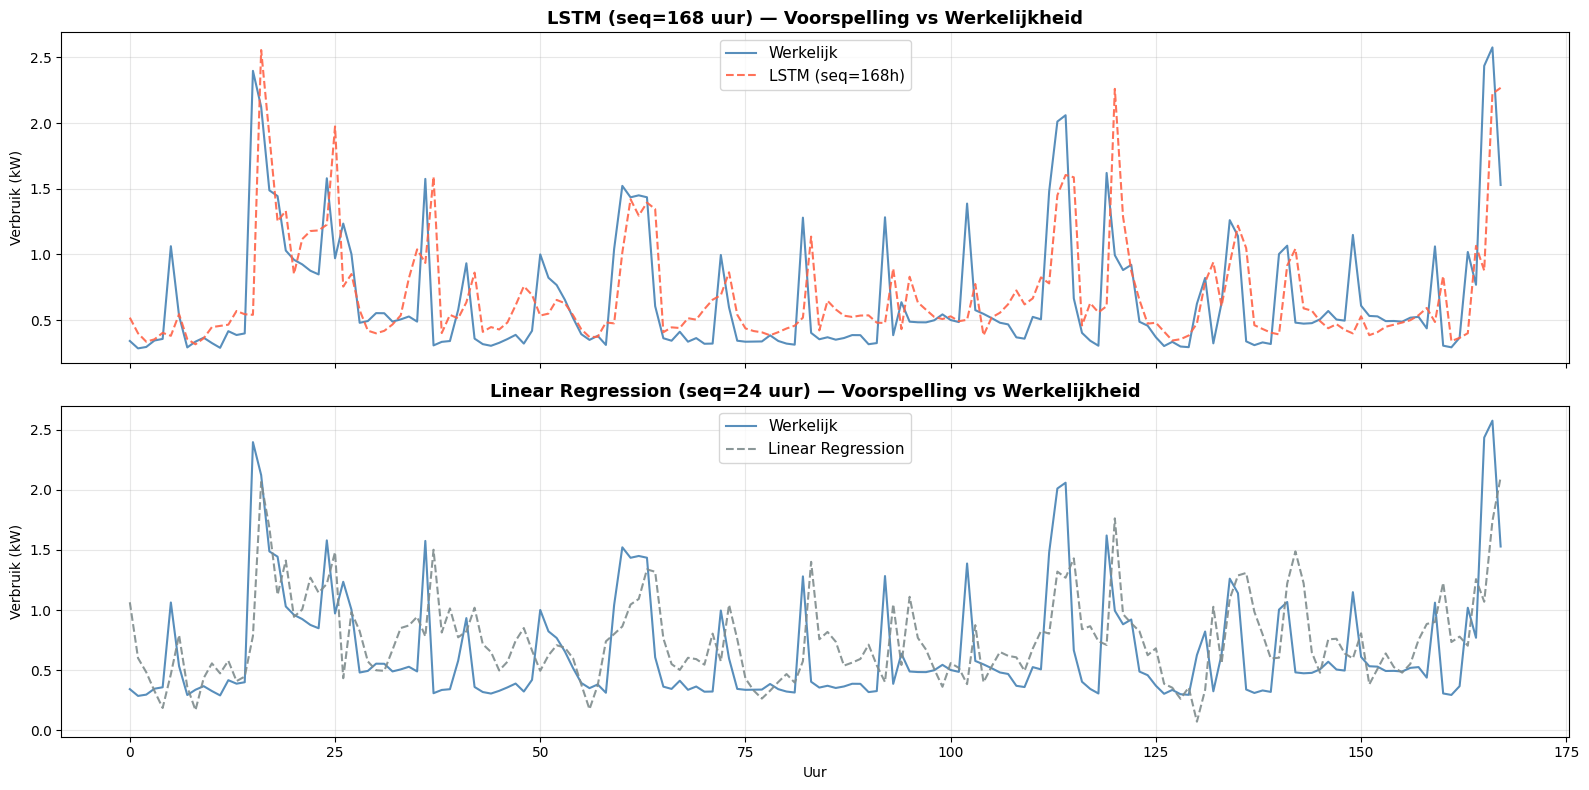

In [14]:
# Selecteer het beste LSTM model (laagste MAE)
best_seq = min(SEQ_LENGTHS, key=lambda s: results[s]['mae'])
best     = results[best_seq]
print(f"Beste model: LSTM seq={best_seq} uur")

# Bereken de overlap — we plotten alleen uren die in BEIDE testsets zitten
# LSTM testset is korter en start later, dus die is leidend
offset = len(y_test_base) - len(best['y_test'])

# Plot een week (168 uur)
start = 500
end   = start + 168

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Dezelfde werkelijke waarden
actual = best['y_test'][start:end]
hours  = range(168)

# LSTM
axes[0].plot(hours, actual,
             color='steelblue', lw=1.5, label='Werkelijk', alpha=0.9)
axes[0].plot(hours, best['y_pred'][start:end],
             color='tomato', lw=1.5, label=f'LSTM (seq={best_seq}h)',
             linestyle='--', alpha=0.9)
axes[0].set_title(f'LSTM (seq={best_seq} uur) — Voorspelling vs Werkelijkheid',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Verbruik (kW)')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# LR — verschoven zodat dezelfde uren geplot worden
lr_start = start + offset
axes[1].plot(hours, actual,
             color='steelblue', lw=1.5, label='Werkelijk', alpha=0.9)
axes[1].plot(hours, y_pred_lr[lr_start:lr_start+168],
             color='#7f8c8d', lw=1.5, label='Linear Regression',
             linestyle='--', alpha=0.9)
axes[1].set_title('Linear Regression (seq=24 uur) — Voorspelling vs Werkelijkheid',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Uur')
axes[1].set_ylabel('Verbruik (kW)')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/04_prediction_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

---
### 11.3 · Verbruik per uur — waar is het model goed/slecht?

We berekenen de gemiddelde fout per uur van de dag.  
Zo zien we of het model moeite heeft met bepaalde momenten (bv. pieken rond kookuren).

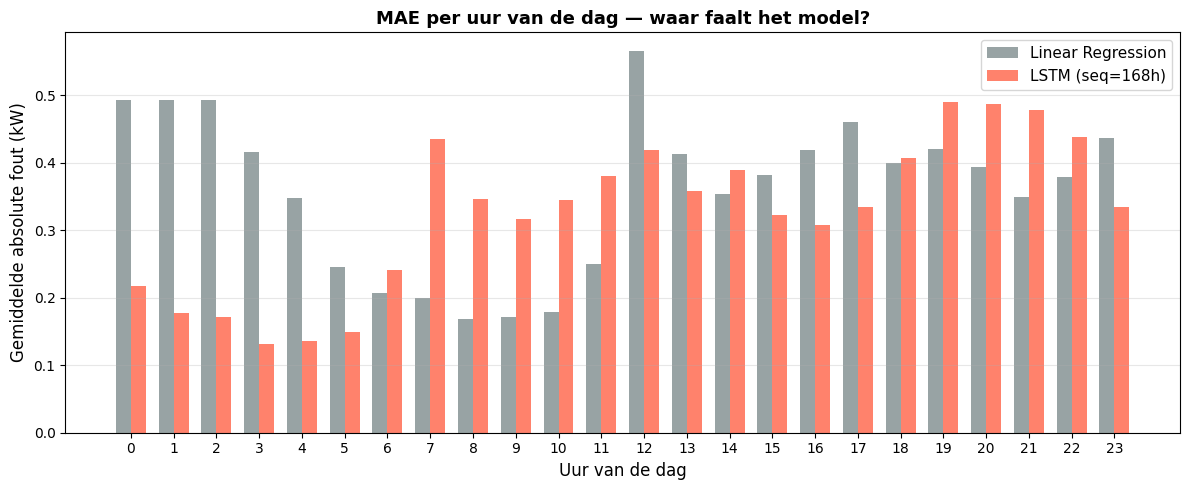

In [15]:
# Bereken MAE per uur van de dag voor het beste LSTM model
test_start_idx = len(df) - len(best['y_test'])
test_hours = df.iloc[test_start_idx : test_start_idx + len(best['y_test'])]['hour'].values

error_by_hour = pd.DataFrame({
    'hour': test_hours,
    'abs_error_lstm': np.abs(best['y_test'] - best['y_pred']),
    'abs_error_lr':   np.abs(y_test_base[:len(test_hours)] - y_pred_lr[:len(test_hours)])
}).groupby('hour').mean()

fig, ax = plt.subplots(figsize=(12, 5))
x = error_by_hour.index
w = 0.35
ax.bar(x - w/2, error_by_hour['abs_error_lr'],   width=w, color='#7f8c8d', label='Linear Regression', alpha=0.8)
ax.bar(x + w/2, error_by_hour['abs_error_lstm'],  width=w, color='tomato',  label=f'LSTM (seq={best_seq}h)', alpha=0.8)
ax.set_xlabel('Uur van de dag', fontsize=12)
ax.set_ylabel('Gemiddelde absolute fout (kW)', fontsize=12)
ax.set_title('MAE per uur van de dag — waar faalt het model?', fontsize=13, fontweight='bold')
ax.set_xticks(range(0, 24))
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/07_error_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()